In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('loan_risk_prediction_dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


Переименование признаков на русский

Для курсовой надо было чтобы все признаки и категории на русском

In [3]:
data = data.rename(columns={'Age': 'Возраст', 'Income': 'Доход',
                           'LoanAmount': 'Сумма кредита', 'CreditScore': 'Кредитный рейтинг',
                           'YearsExperience': 'Трудовой стаж', 'Gender': 'Пол',
                           'Education': 'Образование', 'City': 'Город',
                           'EmploymentType': 'Статус занятости', 'LoanApproved': 'Статус кредита'})
mapping_gender = {'Male': 'Мужской', 'Female': 'Женский'}
mapping_education = {'High School': 'Средняя школа', 'Bachelors': 'Бакалавриат',
                    'Masters': 'Магистратура', 'PhD': 'Аспирантура'}
mapping_city = {'Houston': 'Хьюстон', 'San Francisco': 'Сан-Франциско',
               'New York': 'Нью-Йорк', 'Chicago': 'Чикаго'}
mapping_employed = {'Unemployed': 'Безработный', 'Self-Employed': 'На себя',
                    'Salaried': 'Наемный'}
data['Пол'] = data['Пол'].map(mapping_gender)
data['Образование'] = data['Образование'].map(mapping_education)
data['Город'] = data['Город'].map(mapping_city)
data['Статус занятости'] = data['Статус занятости'].map(mapping_employed)
data.describe()

,Возраст,Доход,Сумма кредита,Кредитный рейтинг,Трудовой стаж,Статус кредита
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


Смотрим выбросы ящиками с усами

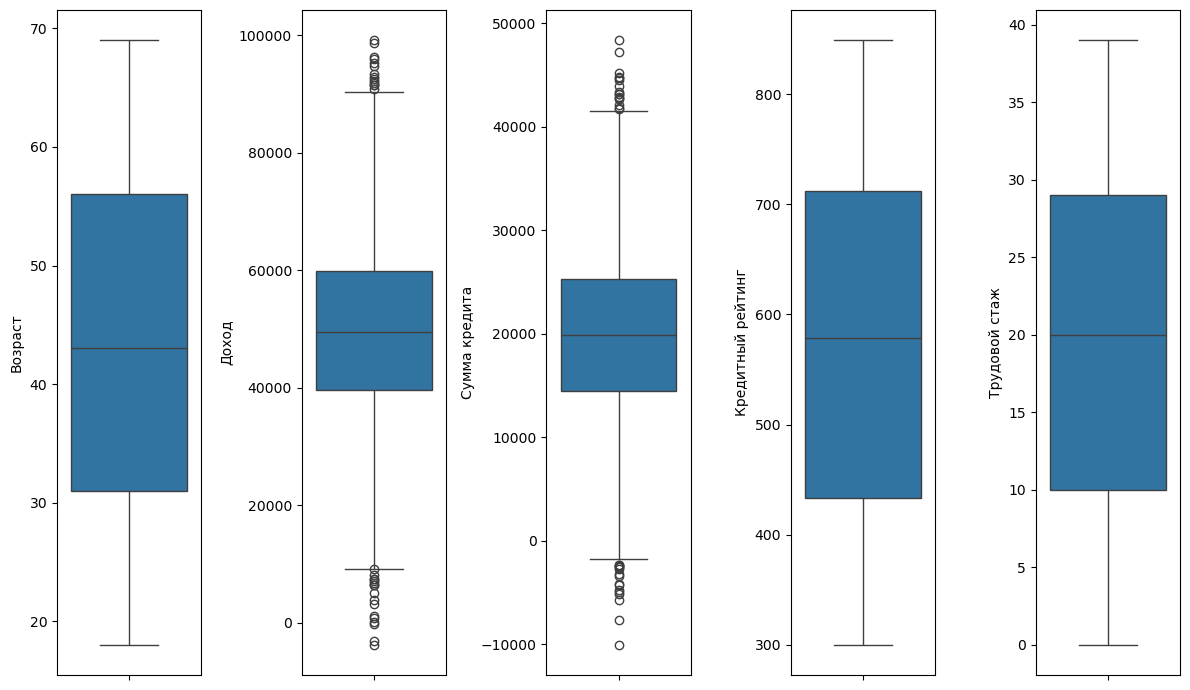

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(12, 7))
for i, col in enumerate(data.select_dtypes(include=['number']).drop('Статус кредита', axis=1).columns):
    sns.boxplot(data=data, y=col, ax=axes[i])
plt.tight_layout()
plt.savefig('boxes.png', dpi=300)
plt.show()

В целом выбросов не так много, стоит только удалить те записи, где
значения отрицательные

Смотрим распределения

In [5]:
data = data.query('Доход > 0 and `Сумма кредита` > 0')

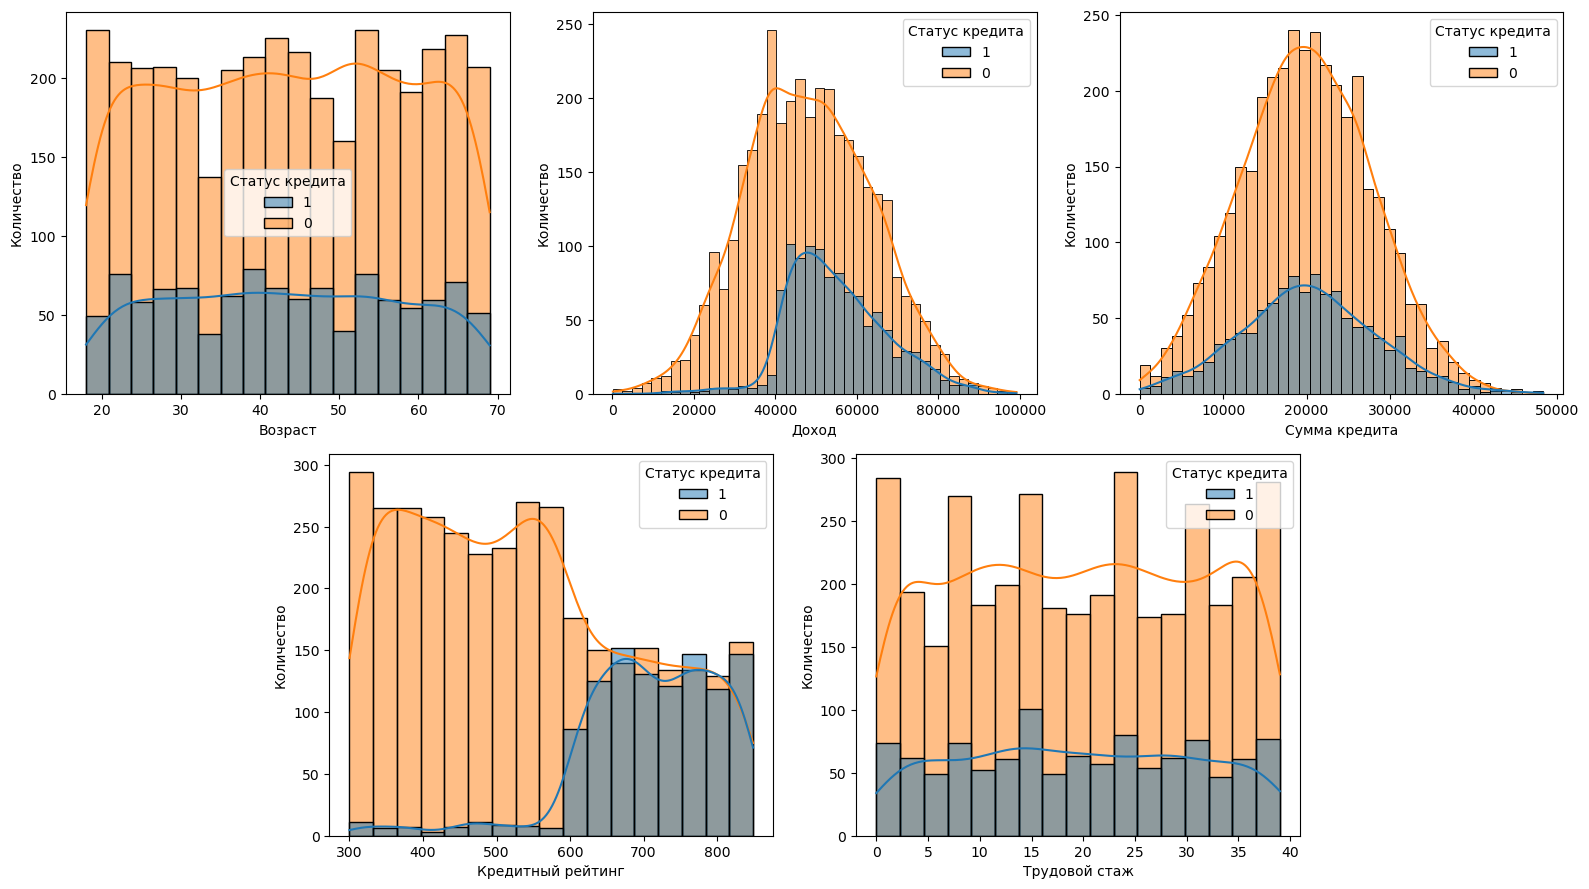

In [6]:
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 6)
axes = [fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5])]
for i, col in enumerate(data.select_dtypes(include=['number']).columns):
    if col != 'Статус кредита':
        sns.histplot(data=data, x=col, ax=axes[i], bins='auto', hue='Статус кредита', hue_order=[1, 0], kde=True)
        axes[i].set_ylabel('Количество')
plt.tight_layout()
plt.savefig('hists.png', dpi=300)
plt.show()

Можно видеть важные нюансы:
если кредитный рейтинг < 600 - почти не выдается кредит
кредит почти всегда выдается тем, у кого доход больше 40 000
многие признаки распределены не нормально

Столбчатые диаграммы

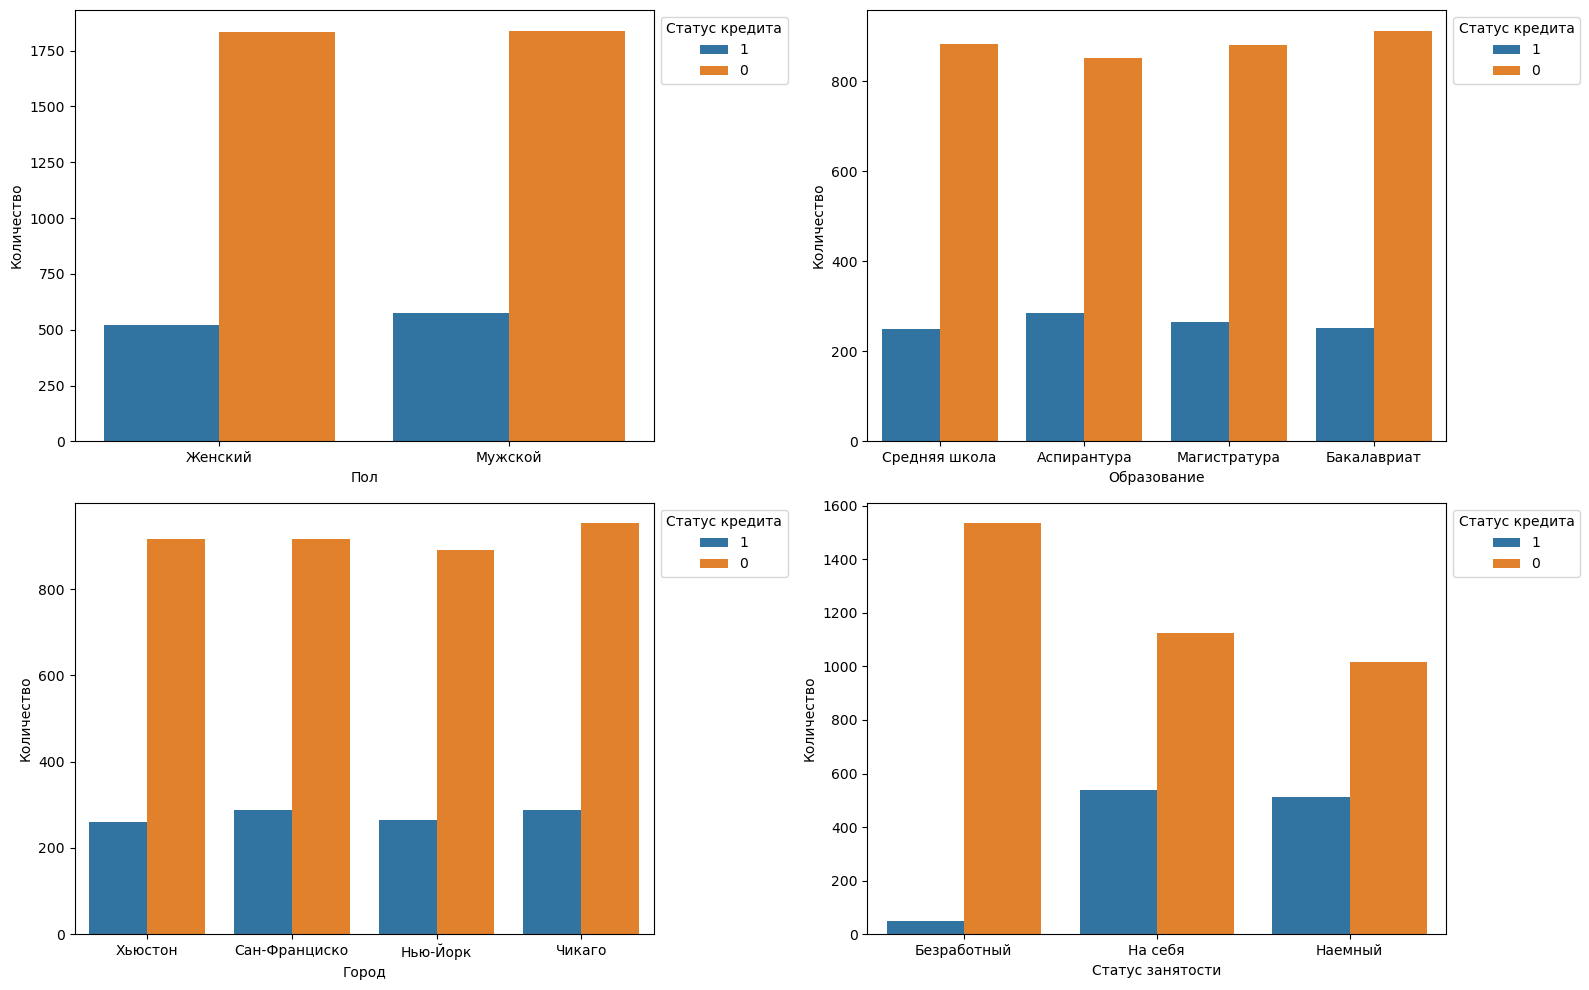

In [7]:
data_gender = data[['Пол', 'Статус кредита']]
data_education = data[['Образование', 'Статус кредита']]
data_city = data[['Город', 'Статус кредита']]
data_employment_type = data[['Статус занятости', 'Статус кредита']]
data_categs = [data_gender, data_education, data_city, data_employment_type]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, data_categ in enumerate(data_categs):
    sns.countplot(data=data_categ, x=data_categ.columns[0], hue='Статус кредита', hue_order=[1, 0], ax=axes[i])
    axes[i].set_ylabel('Количество')
    axes[i].legend(loc='upper left', title='Статус кредита', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('counts.png', dpi=300)
plt.show()

Кажется что кроме статуса занятости остальные признаки не сильно значимы
безработным кредит почти не выдается

Коэффициент корреляции по спирмену, тк признаки многие далеки от нормального
распределения

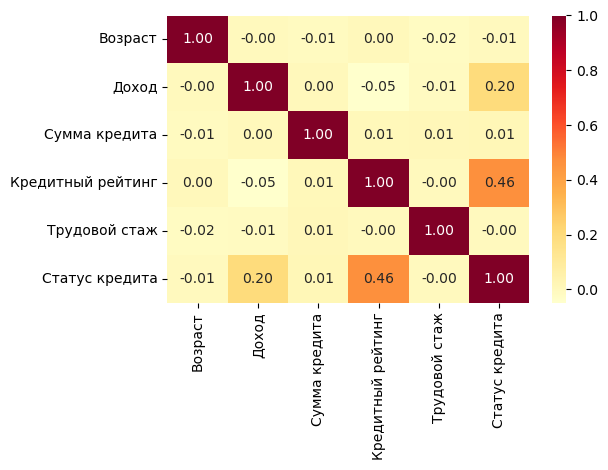

In [8]:
corr = data.corr(method='spearman', numeric_only=True)
sns.heatmap(corr, annot=True, cmap='YlOrRd', fmt='.2f')
plt.tight_layout()
plt.savefig('corr.png', dpi=300)
plt.show()

Признаки между собой не коррелируют, это хорошо для логистической регрессии, так
как возможно отсутствие мультиколлинеарности

Построим звездную диаграмму чтобы посмотреть на средние профили заемщиков

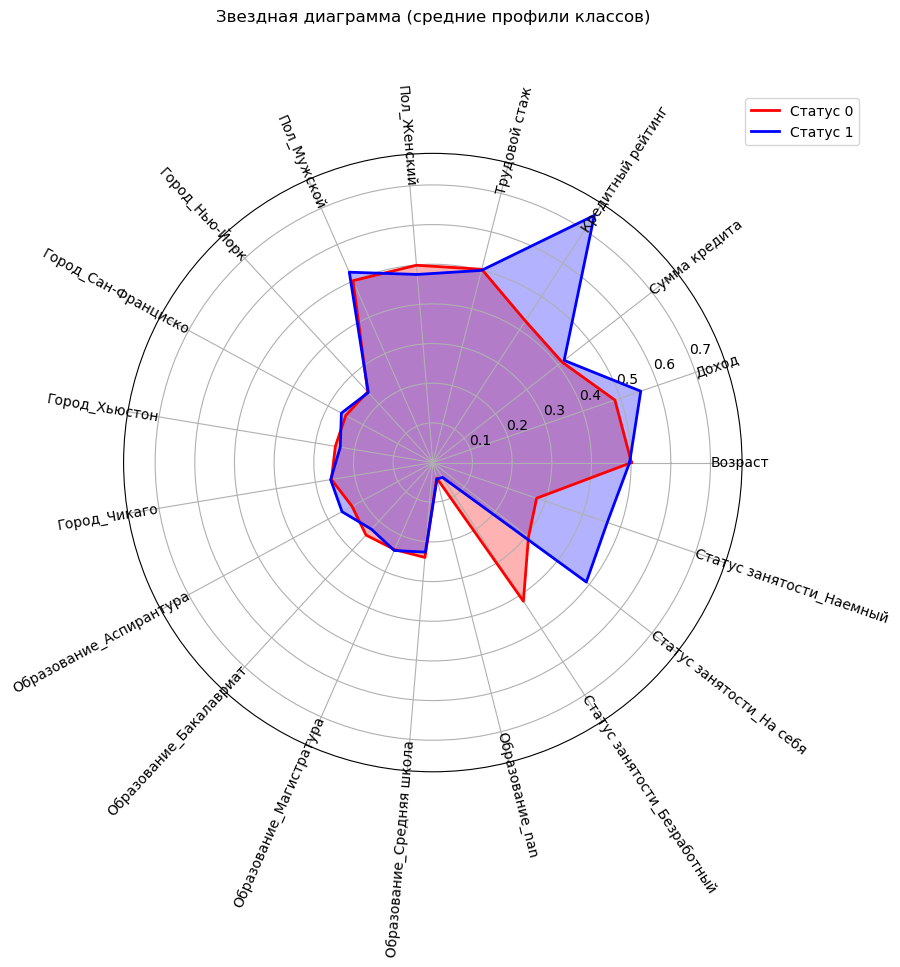

In [9]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

df_encoded = data.copy()
num_cols = ['Возраст', 'Доход', 'Сумма кредита', 'Кредитный рейтинг', 'Трудовой стаж']
cat_cols = ['Пол', 'Город', 'Образование', 'Статус занятости']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = ohe.fit_transform(df_encoded[cat_cols])
cat_feature_names = ohe.get_feature_names_out(cat_cols)
df_cats = pd.DataFrame(encoded_cats, columns=cat_feature_names, index=df_encoded.index)
df_encoded = pd.concat([df_encoded[num_cols], df_cats, df_encoded['Статус кредита']], axis=1)
features_to_scale = num_cols + list(cat_feature_names)
scaler = MinMaxScaler()
df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

mean_df = df_encoded.groupby('Статус кредита').mean().reset_index()
num_vars = len(features_to_scale)

# Вычисление углов для осей
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Замыкание круга

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = ['red', 'blue']

for i, row in mean_df.iterrows():
    values = row[features_to_scale].values.tolist()
    values += values[:1]  # Замыкание круга
    ax.plot(angles, values, label=f"Статус {int(row['Статус кредита'])}", linewidth=2, color=colors[i])
    ax.fill(angles, values, alpha=0.3, color=colors[i])

ax.set_xticks(angles[:-1])

# Настройка подписей с динамическим поворотом
labels = []
padding = 0.7  # Коэффициент удаления текста от центра (подберите под себя)

for angle, feature in zip(angles[:-1], features_to_scale):
    # Переводим радианы в градусы
    angle_deg = np.rad2deg(angle)
    
    # Вычисляем правильный поворот, чтобы текст было удобно читать
    if 90 <= angle_deg <= 270:
        rotation = angle_deg + 180
        ha = 'right'
    else:
        rotation = angle_deg
        ha = 'left'
        
    # Выравнивание по вертикали в зависимости от положения
    va = 'center'
    
    # Добавляем кастомный текст на график
    ax.text(angle, padding, feature, 
            rotation=rotation, 
            rotation_mode='anchor', 
            horizontalalignment=ha, 
            verticalalignment=va,
            fontsize=10)

# Выключаем стандартные радиальные подписи, так как мы нарисовали свои
ax.set_xticklabels([]) 

plt.title('Звездная диаграмма (средние профили классов)', y=1.2) # Сдвигаем заголовок чуть выше
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1)) # Сдвигаем легенду, чтобы не мешала
plt.tight_layout()
plt.savefig('star.png', dpi=300)
plt.show()

Красиво видны профили:
средний человек, которому не одобрили - безработный или с низким уровнем дохода
или низким кредитным рейтингом
с тем, кому одобрили, все наоборот

Так как один из оцениваемых алгоритмов классификации будет Наивный Байес
а он работает с признаками так, будто они независимы, отберу статистически
значимые признаки

In [14]:
data = data.dropna()

In [15]:
from scipy.stats import mannwhitneyu

for col in num_cols:
    group0 = data[data['Статус кредита'] == 0][col]
    group1 = data[data['Статус кредита'] == 1][col]
    stat, p = mannwhitneyu(group0, group1)
    print(f'{col}: p-val = {p:.7f}')

Возраст: p-val = 0.4885751
Доход: p-val = 0.0000000
Сумма кредита: p-val = 0.4092492
Кредитный рейтинг: p-val = 0.0000000
Трудовой стаж: p-val = 0.4554037


Вероятно, можно будет удалить признаки возраст, сумма кредита и трудовой стаж

In [16]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    contingency_table = pd.crosstab(data[col], data['Статус кредита'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    print(f'{col}: p-val = {p:.4f}')

Пол: p-val = 0.2096
Город: p-val = 0.8717
Образование: p-val = 0.1943
Статус занятости: p-val = 0.0000


Похоже, роляет только статус занятости

In [17]:
data_only_important = data.drop(columns=['Пол', 'Город', 'Образование',
                                        'Возраст', 'Сумма кредита', 'Трудовой стаж'],
                                axis=1)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

X_bayes = data_only_important.drop(['Статус кредита', 'Метки'], axis=1, errors='ignore')
y_bayes = data_only_important['Статус кредита']

X_train_bayes, X_test_bayes, y_train_bayes, y_test_bayes = train_test_split(
    X_bayes, y_bayes, test_size=0.2, random_state=42)

preprocessor_bayes = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['Доход', 'Кредитный рейтинг']),
        ('cat', OneHotEncoder(), ['Статус занятости'])
    ])

bayes_model = Pipeline(steps=[
    ('preprocessor', preprocessor_bayes),
    ('classifier', GaussianNB())
])

bayes_model.fit(X_train_bayes, y_train_bayes)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Доход',
                                                   'Кредитный рейтинг']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Статус занятости'])])),
                ('classifier', GaussianNB())])

In [19]:
y_pred_bayes = bayes_model.predict(X_test_bayes)
print(classification_report(y_test_bayes, y_pred_bayes))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       664
           1       0.86      0.78      0.82       217

    accuracy                           0.91       881
   macro avg       0.90      0.87      0.88       881
weighted avg       0.91      0.91      0.91       881



Ключевые метрики, которые надо сравнивать:
precision для класса 1
recall для класса 0
потому что обе метрики штрафуются за выдачу кредита ненадежному заемщику, что критично

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

num_cols = ['Возраст', 'Доход', 'Сумма кредита', 'Кредитный рейтинг', 'Трудовой стаж']
categ_cols = ['Пол', 'Город', 'Образование', 'Статус занятости']

X_log = data.drop(['Статус кредита', 'Метки'], axis=1, errors='ignore')
y_log = data['Статус кредита']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42)

preprocessor_log = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), categ_cols)
    ])

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor_log),
    ('classifier', LogisticRegression())
])

log_model.fit(X_train_log, y_train_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Возраст', 'Доход',
                                                   'Сумма кредита',
                                                   'Кредитный рейтинг',
                                                   'Трудовой стаж']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Пол', 'Город',
                                                   'Образование',
                                                   'Статус занятости'])])),
                ('classifier', LogisticRegression())])

In [21]:
y_pred_log = log_model.predict(X_test_log)
print(classification_report(y_test_log, y_pred_log))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       664
           1       0.81      0.71      0.76       217

    accuracy                           0.89       881
   macro avg       0.86      0.83      0.84       881
weighted avg       0.88      0.89      0.88       881



In [22]:
from sklearn.ensemble import RandomForestClassifier

num_cols = ['Возраст', 'Доход', 'Сумма кредита', 'Кредитный рейтинг', 'Трудовой стаж']
categ_cols = ['Пол', 'Город', 'Образование', 'Статус занятости']

X_forest = data.drop(['Статус кредита', 'Метки'], axis=1, errors='ignore')
y_forest = data['Статус кредита']

X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(
    X_forest, y_forest, test_size=0.2, random_state=42)

preprocessor_forest = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(), categ_cols)
    ])

forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor_forest),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

forest_model.fit(X_train_forest, y_train_forest)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Возраст', 'Доход',
                                                   'Сумма кредита',
                                                   'Кредитный рейтинг',
                                                   'Трудовой стаж']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Пол', 'Город',
                                                   'Образование',
                                                   'Статус занятости'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [23]:
y_pred_forest = forest_model.predict(X_test_forest)
print(classification_report(y_test_forest, y_pred_forest))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       664
           1       0.96      0.90      0.93       217

    accuracy                           0.97       881
   macro avg       0.96      0.95      0.95       881
weighted avg       0.97      0.97      0.97       881



In [25]:
from catboost import CatBoostClassifier
X_boost = data.drop(['Статус кредита', 'Метки'], axis=1, errors='ignore')
y_boost = data['Статус кредита']
categ_cols = ['Пол', 'Город', 'Образование', 'Статус занятости']

X_train_boost, X_test_boost, y_train_boost, y_test_boost = train_test_split(
    X_boost, y_boost, test_size=0.2, random_state=42)

boost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    cat_features=categ_cols,
    verbose=False
)

boost_model.fit(X_train_boost, y_train_boost)

CatBoostClassifier(cat_features=['Пол', 'Город', 'Образование', 'Статус занятости'], depth=6, iterations=100, learning_rate=0.1, verbose=False)

In [26]:
y_pred_boost = boost_model.predict(X_test_boost)
print(classification_report(y_test_boost, y_pred_boost))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       664
           1       0.96      0.89      0.93       217

    accuracy                           0.96       881
   macro avg       0.96      0.94      0.95       881
weighted avg       0.96      0.96      0.96       881



Теперь precision-recall кривые для наглядной оценки, как модели
справляются с классом 1

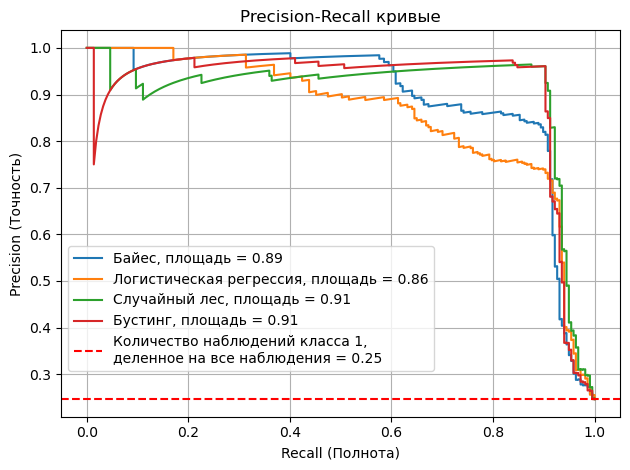

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score
baseline = np.sum(y_test_bayes == 1) / len(y_test_bayes)

y_probs_bayes = bayes_model.predict_proba(X_test_bayes)[:, 1]
pr_auc_bayes = average_precision_score(y_test_bayes, y_probs_bayes)

y_probs_log = log_model.predict_proba(X_test_log)[:, 1]
pr_auc_log = average_precision_score(y_test_log, y_probs_log)

y_probs_forest = forest_model.predict_proba(X_test_forest)[:, 1]
pr_auc_forest = average_precision_score(y_test_forest, y_probs_forest)

y_probs_boost = boost_model.predict_proba(X_test_boost)[:, 1]
pr_auc_boost = average_precision_score(y_test_boost, y_probs_boost)

precision_bayes, recall_bayes, _ = precision_recall_curve(y_test_bayes, y_probs_bayes)
plt.plot(recall_bayes, precision_bayes, label=f'Байес, площадь = {pr_auc_bayes:.2f}')

precision_log, recall_log, _ = precision_recall_curve(y_test_log, y_probs_log)
plt.plot(recall_log, precision_log, label=f'Логистическая регрессия, площадь = {pr_auc_log:.2f}')

precision_forest, recall_forest, _ = precision_recall_curve(y_test_forest, y_probs_forest)
plt.plot(recall_forest, precision_forest, label=f'Случайный лес, площадь = {pr_auc_forest:.2f}')

precision_boost, recall_boost, _ = precision_recall_curve(y_test_boost, y_probs_boost)
plt.plot(recall_boost, precision_boost, label=f'Бустинг, площадь = {pr_auc_boost:.2f}')

plt.axhline(y=baseline, color='red', linestyle='--', label=f'Количество наблюдений класса 1,\nделенное на все наблюдения = {baseline:.2f}')
plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.title('Precision-Recall кривые')
plt.legend(loc='lower left', bbox_to_anchor=(0, 0.1))
plt.grid(True)
plt.tight_layout()
plt.savefig('pr.png', dpi=300)
plt.show()

Кэтбуст и рандом форест гораздо лучше по качеству

Веса логистической регрессии на графике

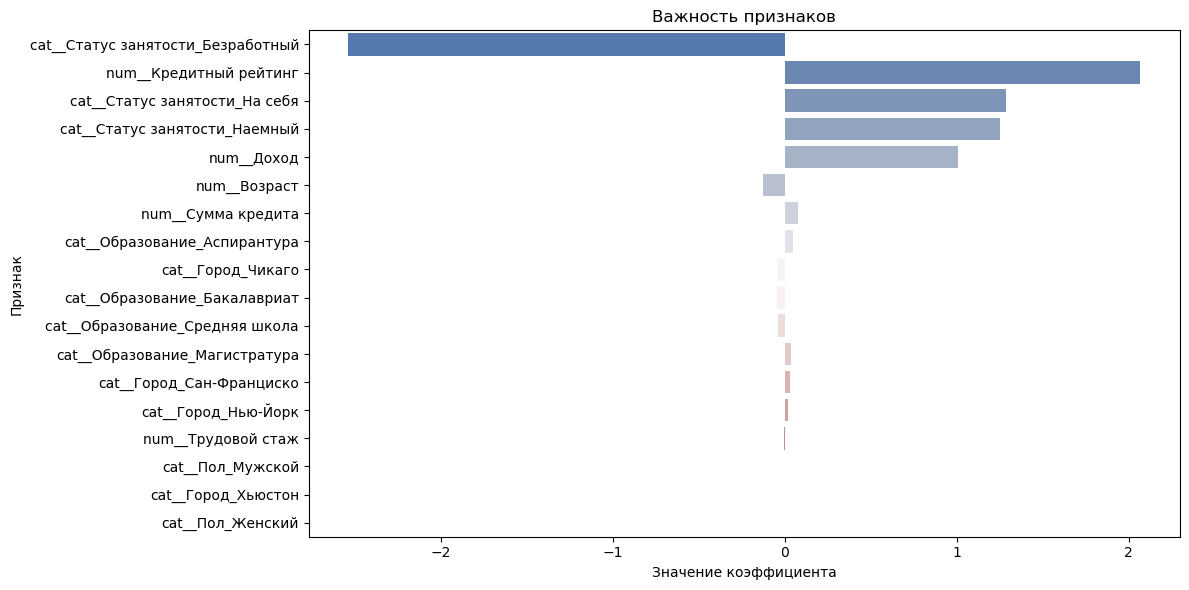

In [28]:
log_feat_names = log_model.named_steps['preprocessor'].get_feature_names_out()
log_coefs = log_model.named_steps['classifier'].coef_.flatten()

log_coefs_df = pd.DataFrame({
    'Признак': log_feat_names,
    'Коэффициент': log_coefs
}).sort_values(by='Коэффициент', ascending=False)

plt.figure(figsize=(12, 6))

plot = sns.barplot(
    data=log_coefs_df.reindex(log_coefs_df.Коэффициент.abs().sort_values(ascending=False).index),
    x='Коэффициент',
    y='Признак',
    palette='vlag',
    hue='Признак',
    legend=False
)

plt.title('Важность признаков')
plt.xlabel('Значение коэффициента')
plt.ylabel('Признак')
plt.tight_layout()
plt.savefig('logcoefs.png', dpi=300)
plt.show()

А чтобы посмотреть какие признаки какой вклад вносят в ансамблевых, 
построю графики пчелиный рой, использующие значения Шепли

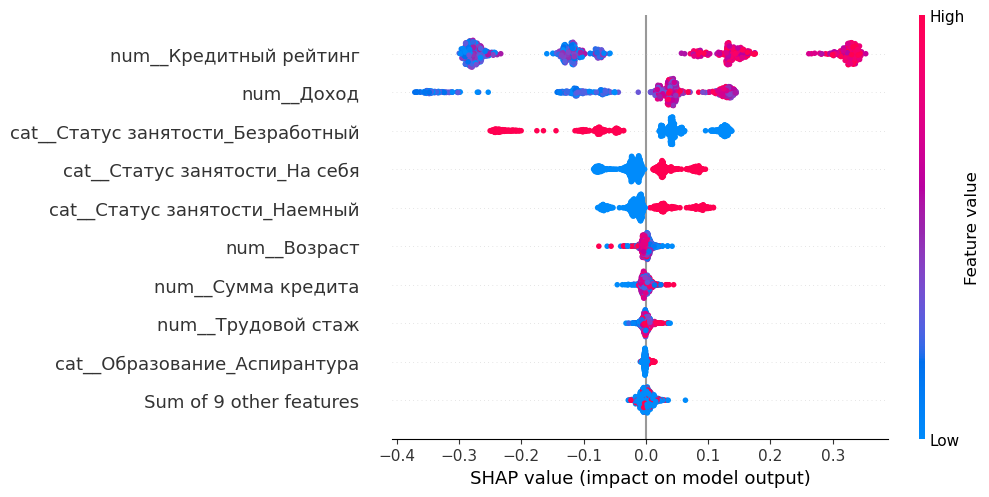

In [29]:
import shap

model = forest_model.named_steps['classifier']
preproc = forest_model.named_steps['preprocessor']

X_test_forest_transformed = preproc.transform(X_test_forest)
feature_names = preproc.get_feature_names_out()

X_test_forest_df = pd.DataFrame(X_test_forest_transformed, columns=feature_names)
explainer = shap.TreeExplainer(model)
explanation = explainer(X_test_forest_df)

shap.plots.beeswarm(explanation[:, :, 1], show=False)
plt.savefig('beeswarm.png', bbox_inches='tight', dpi=300)
plt.show()

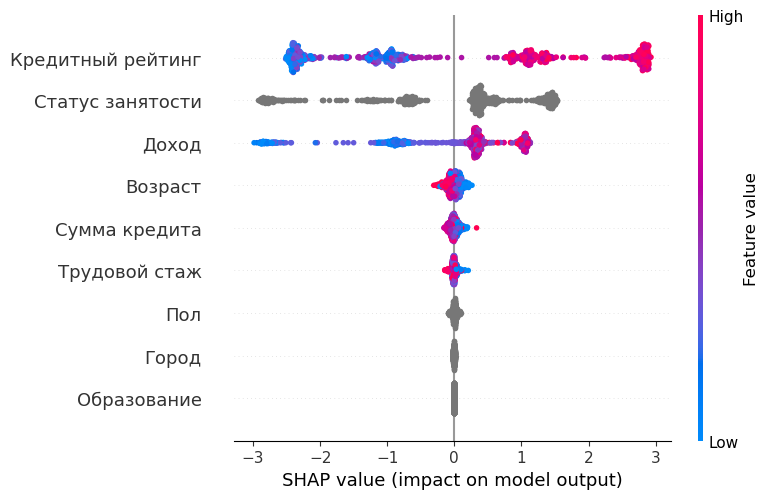

In [30]:
from catboost import Pool
categ_cols = ['Пол', 'Город', 'Образование', 'Статус занятости']
data_pool = Pool(X_test_boost, label=y_test_boost, cat_features=categ_cols)
shap_results = boost_model.get_feature_importance(data_pool, type='ShapValues')
expected_value = shap_results[0, -1]
shap_values = shap_results[:, :-1]

shap.summary_plot(shap_values, X_test_boost, feature_names=boost_model.feature_names_, show=False)
plt.savefig('sum_plot.png', bbox_inches='tight', dpi=300)
plt.show()

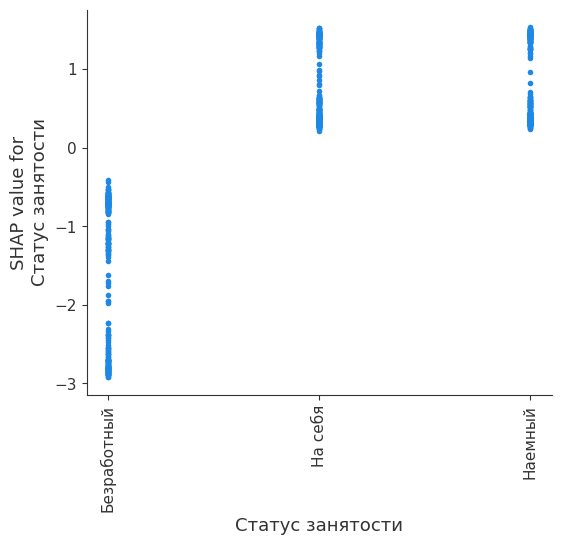

In [31]:
shap.dependence_plot('Статус занятости', shap_values, X_test_boost,
                     display_features=X_test_boost, interaction_index=None, show=False)
plt.savefig('dependence.png', bbox_inches='tight', dpi=300)
plt.show()

В рамках моей курсовой лучше всего себя показали ансамбли, а конкретно
Кэтбуст не требует предварительной кодировки категориальных признаков,
поэтому он будет лучшим выбором